# PHASE 2: Data Cleaning & EDA
**Traceability**
- Issue ID: #2 Data Cleaning & EDA

**External References**:
- [Wassim Derbel - NASA Predictive Maintenance](https://www.kaggle.com/code/wassimderbel/nasa-predictive-maintenance-rul) (Constant Sensor Removal)
- [Carl Kirstein - Predictive Maintenance](https://www.kaggle.com/code/carlkirstein/predictive-maintenance-nasa-turbofan-regression) (Outlier Handling)
- [Carl Kirstein - Predictive Maintenance](https://www.kaggle.com/code/carlkirstein/predictive-maintenance-nasa-turbofan-regression) (Correlation Analysis)
- [Wassim Derbel - NASA Predictive Maintenance](https://www.kaggle.com/code/wassimderbel/nasa-predictive-maintenance-rul) (Trend Visualization)

## 1. Objectives
- **Diagnostic**: Identify sensors with zero variance (constant).
- **Action**: Remove constant sensors to reduce dimensionality.
- **Diagnostic**: Analyze engine lifetime distribution to set RUL targets.
- **Diagnostic**: Visualize sensor degradation trends to identify predictive features.
- **Diagnostic**: Compute correlation matrix to detect multicollinearity.
- **Action**: Inform feature selection and engineering strategies.
- **Diagnostic**: Detect outliers using statistical distribution plots.
- **Action**: Clip outliers to 1st/99th percentiles to preserve temporal continuity.

In [118]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

# ── Plotting Config ───────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})
COLORS = ['#1F4E79', '#2E75B6', '#70AD47', '#FF7043', '#AB47BC']
COLORSplt = ['#313695', '#4575B4', '#FFFFFF', '#FEE090', '#D73027']

# ── Reproducibility Config ──────────────────────────────────────────────
np.random.seed(42)

# ── Global Config ────────────────────────────────────────────────────────
DATA_DIR = Path('../data')
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

COL_NAMES = (
    ['unit_number', 'time_cycles'] +
    ['setting_1', 'setting_2', 'setting_3'] +
    [f's_{i}' for i in range(1, 22)]   # s_1 ... s_21
)

### 2.1 Load Raw Data
Load the raw training and test data.

In [119]:
df_train = pd.read_csv(DATA_DIR / 'train_FD001.txt', sep=r'\s+', header=None, index_col=False, names=COL_NAMES)
df_test = pd.read_csv(DATA_DIR / 'test_FD001.txt', sep=r'\s+', header=None, index_col=False, names=COL_NAMES)
print(f"✅ Data loaded: Train {df_train.shape}, Test {df_test.shape}")

✅ Data loaded: Train (20631, 26), Test (13096, 26)


### 2.2 Diagnostic: Sensor Variance Analysis
We visualize the standard deviation of each sensor to identify those that do not change over time (constant sensors). These provide no predictive value.

s_1: 0.0000
s_19: 0.0000
s_18: 0.0000
s_10: 0.0000
s_16: 0.0000
s_5: 0.0000
s_6: 0.0014
s_15: 0.0375
s_8: 0.0710
s_13: 0.0719
s_21: 0.1083
s_20: 0.1807
s_11: 0.2671
s_2: 0.5001
s_12: 0.7376
s_7: 0.8851
s_17: 1.5488
s_3: 6.1311
s_4: 9.0006
s_14: 19.0762
s_9: 22.0829


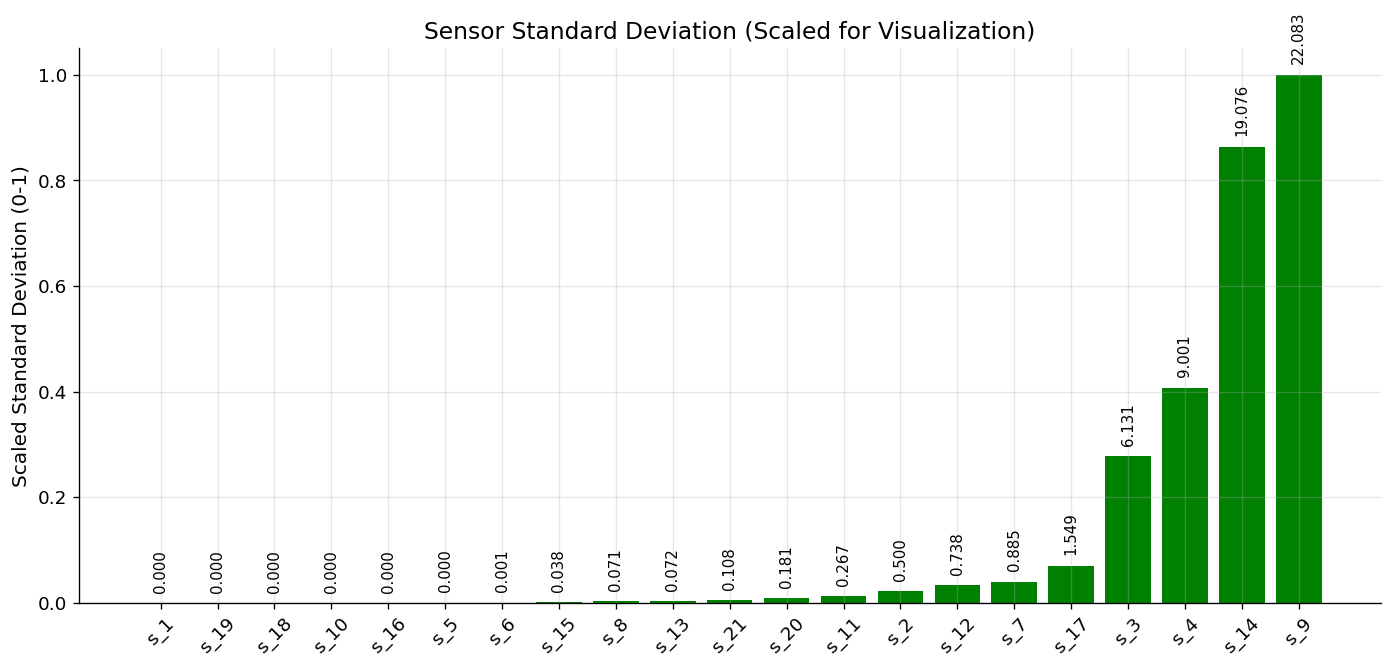

In [120]:
def visualize_sensor_variance_scaled(df, threshold=0.01):
    sensor_cols = [f's_{i}' for i in range(1, 22)]
    sensor_std = df[sensor_cols].std().sort_values()
    
    # Min-Max scaling to 0-1 range
    scaler = MinMaxScaler()
    sensor_std_scaled = scaler.fit_transform(sensor_std.values.reshape(-1, 1)).flatten()
    
    plt.figure(figsize=(14,6))
    colors = ['red' if std < threshold else 'green' for std in sensor_std]  # threshold still in original scale
    
    bars = plt.bar(sensor_std.index, sensor_std_scaled, color=colors)
    
    # Annotate with original std values
    for bar, orig_std in zip(bars, sensor_std.values):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{orig_std:.3f}',
                 ha='center', va='bottom', fontsize=9, rotation=90)
    
    plt.title('Sensor Standard Deviation (Scaled for Visualization)', fontsize=14)
    plt.ylabel('Scaled Standard Deviation (0-1)', fontsize=12)
    plt.xticks(rotation=45)
    plt.show()
    
    return sensor_std[sensor_std < threshold].index.tolist()

# Compute std for each sensor
sensor_std = df_train[[f's_{i}' for i in range(1, 22)]].std()
# Sort by std
sensor_std_sorted = sensor_std.sort_values()
# Print each sensor with its std
for sensor_name, std_val in sensor_std_sorted.items():
    print(f"{sensor_name}: {std_val:.4f}")

constant_sensors = visualize_sensor_variance_scaled(df_train)

Anything with std ≈ 0 can be safely dropped: s_1, s_5, s_10, s_16, s_18, s_19

Lets say threshold = 0.01

Low but not zero (s_6, s_8, s_15) — might be near-constant. 
Can consider dropping later if they don’t correlate with RUL.

In [121]:
def add_RUL_column(df):
    train_grouped_by_unit = df.groupby(by='unit_number') 
    max_time_cycles = train_grouped_by_unit['time_cycles'].max() 
    merged = df.merge(max_time_cycles.to_frame(name='max_time_cycle'), left_on='unit_number',right_index=True)
    merged["RUL"] = merged["max_time_cycle"] - merged['time_cycles']
    merged = merged.drop("max_time_cycle", axis=1) 
    return merged
train = add_RUL_column(df_train)
train[['unit_number','RUL']]

,unit_number,RUL
0,1,191
1,1,190
2,1,189
3,1,188
4,1,187
...,...,...
20626,100,4
20627,100,3
20628,100,2
20629,100,1


In [122]:
#Rul analysis
maxrul_u = train.groupby('unit_number').max().reset_index()
maxrul_u.head()

,unit_number,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,192,0.0047,0.0005,100.0,518.67,644.21,1605.44,1432.52,14.62,...,2388.35,8140.58,8.5227,0.03,398,2388,100.0,39.18,23.4999,191
1,2,287,0.0076,0.0006,100.0,518.67,643.94,1610.10,1431.17,14.62,...,2388.26,8175.57,8.5377,0.03,398,2388,100.0,39.24,23.6005,286
2,3,179,0.0058,0.0005,100.0,518.67,643.93,1606.50,1438.51,14.62,...,2388.20,8255.34,8.5363,0.03,399,2388,100.0,39.23,23.5181,178
3,4,189,0.0059,0.0006,100.0,518.67,644.53,1612.11,1434.12,14.62,...,2388.17,8259.42,8.5462,0.03,399,2388,100.0,39.21,23.5074,188
4,5,269,0.0055,0.0005,100.0,518.67,644.02,1609.41,1434.59,14.62,...,2388.23,8215.19,8.5410,0.03,398,2388,100.0,39.29,23.5503,268


Visualize on RUL column correlation with sensor columns

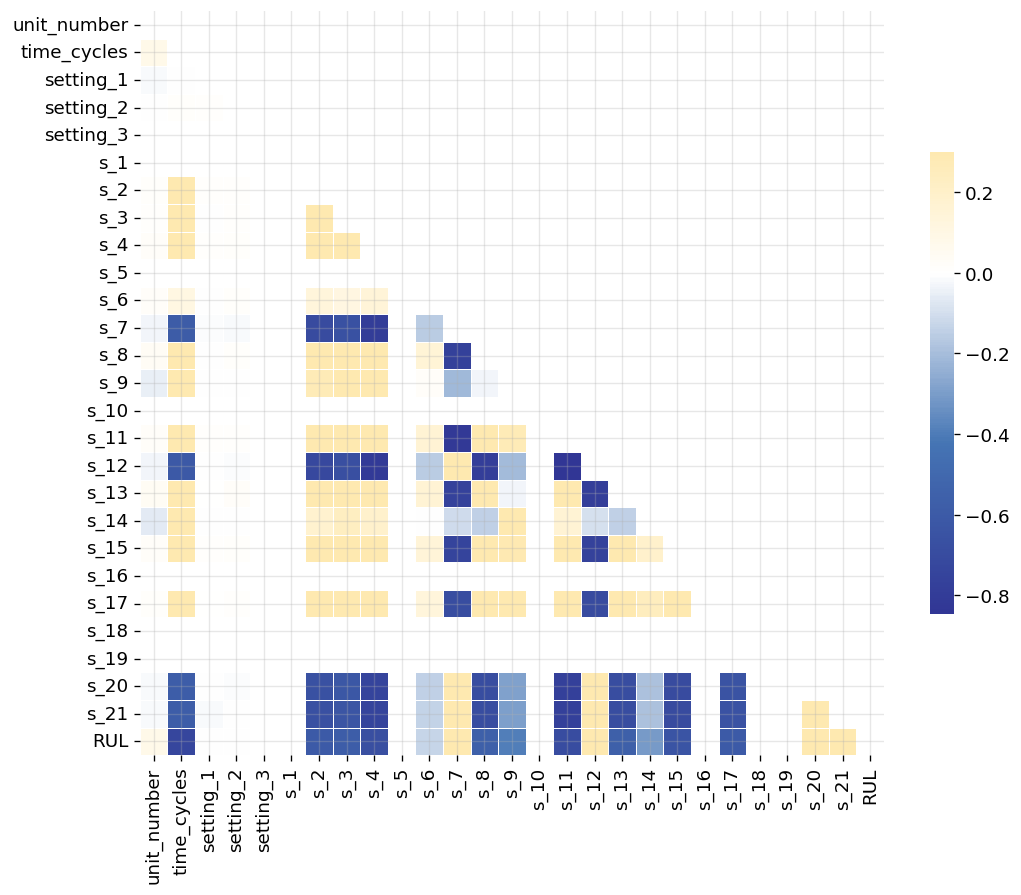

In [123]:
# Create a colormap from your colors
cmap = LinearSegmentedColormap.from_list("custom_cmap", COLORSplt)

# Compute the correlation matrix
corr = train.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(10, 10))

# Draw the heatmap
sns.heatmap(
    corr, 
    mask=mask, 
    cmap=cmap,        # use your custom colormap
    vmax=.3, 
    center=0, 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .5}
)

plt.show()


Can be safely dropped: s_1, s_5, s_10, s_16, s_18, s_19

Not sure: (s_6, s_8, s_15) — might be near-constant. 

Need further analysis to confirm if these sensors are indeed constant or just near-constant.

We notice that some features of our data-set are highly correlated with the target value RUL, other features present a low correlation which will be dropped later.


In [124]:
# List of sensors to drop
sensors_to_drop = ['s_1', 's_5', 's_10', 's_16', 's_18', 's_19']

# Drop from train and test safely
df_train = df_train.drop(columns=sensors_to_drop, errors='ignore')
df_test = df_test.drop(columns=sensors_to_drop, errors='ignore')

# Remaining sensors
remaining_sensors = [c for c in df_train.columns if c.startswith('s_')]

print(f"✅ Dropped sensors_to_drop: {sensors_to_drop} . Remaining: {len(remaining_sensors)}")


✅ Dropped sensors_to_drop: ['s_1', 's_5', 's_10', 's_16', 's_18', 's_19'] . Remaining: 15


In [125]:
# Original Sensor_dictionary creation
dict_list = [
    "(Fan inlet temperature) (◦R)",
    "(LPC outlet temperature) (◦R)",
    "(HPC outlet temperature) (◦R)",
    "(LPT outlet temperature) (◦R)",
    "(Fan inlet Pressure) (psia)",
    "(bypass-duct pressure) (psia)",
    "(HPC outlet pressure) (psia)",
    "(Physical fan speed) (rpm)",
    "(Physical core speed) (rpm)",
    "(Engine pressure ratio(P50/P2)",
    "(HPC outlet Static pressure) (psia)",
    "(Ratio of fuel flow to Ps30) (pps/psia)",
    "(Corrected fan speed) (rpm)",
    "(Corrected core speed) (rpm)",
    "(Bypass Ratio) ",
    "(Burner fuel-air ratio)",
    "(Bleed Enthalpy)",
    "(Required fan speed)",
    "(Required fan conversion speed)",
    "(High-pressure turbines Cool air flow)",
    "(Low-pressure turbines Cool air flow)"
]

# Map all sensors
Sensor_dictionary = {f's_{i+1}': name for i, name in enumerate(dict_list)}

# Keep only the sensors that still exist in df_train
remaining_sensors = [c for c in df_train.columns if c.startswith('s_')]
Sensor_dictionary = {k: v for k, v in Sensor_dictionary.items() if k in remaining_sensors}

Sensor_dictionary

{'s_2': '(LPC outlet temperature) (◦R)',
 's_3': '(HPC outlet temperature) (◦R)',
 's_4': '(LPT outlet temperature) (◦R)',
 's_6': '(bypass-duct pressure) (psia)',
 's_7': '(HPC outlet pressure) (psia)',
 's_8': '(Physical fan speed) (rpm)',
 's_9': '(Physical core speed) (rpm)',
 's_11': '(HPC outlet Static pressure) (psia)',
 's_12': '(Ratio of fuel flow to Ps30) (pps/psia)',
 's_13': '(Corrected fan speed) (rpm)',
 's_14': '(Corrected core speed) (rpm)',
 's_15': '(Bypass Ratio) ',
 's_17': '(Bleed Enthalpy)',
 's_20': '(High-pressure turbines Cool air flow)',
 's_21': '(Low-pressure turbines Cool air flow)'}

A low pressure compressor **(LPC)** and high pressure compressor **(HPC)** supply compressed high temperature, high pressure gases to the combustor. Low pressure turbine **(LPT)** can decelerate and pressurize air to improve the chemical energy conversion efficiency of aviation kerosene. High pressure turbines **(HPT)** generate mechanical energy by using high temperature and high pressure gas strike turbine blades. **Low-pressure rotor (N1), high-pressure rotor (N2), and nozzle** guarantee the combustion efficiency of the engine.

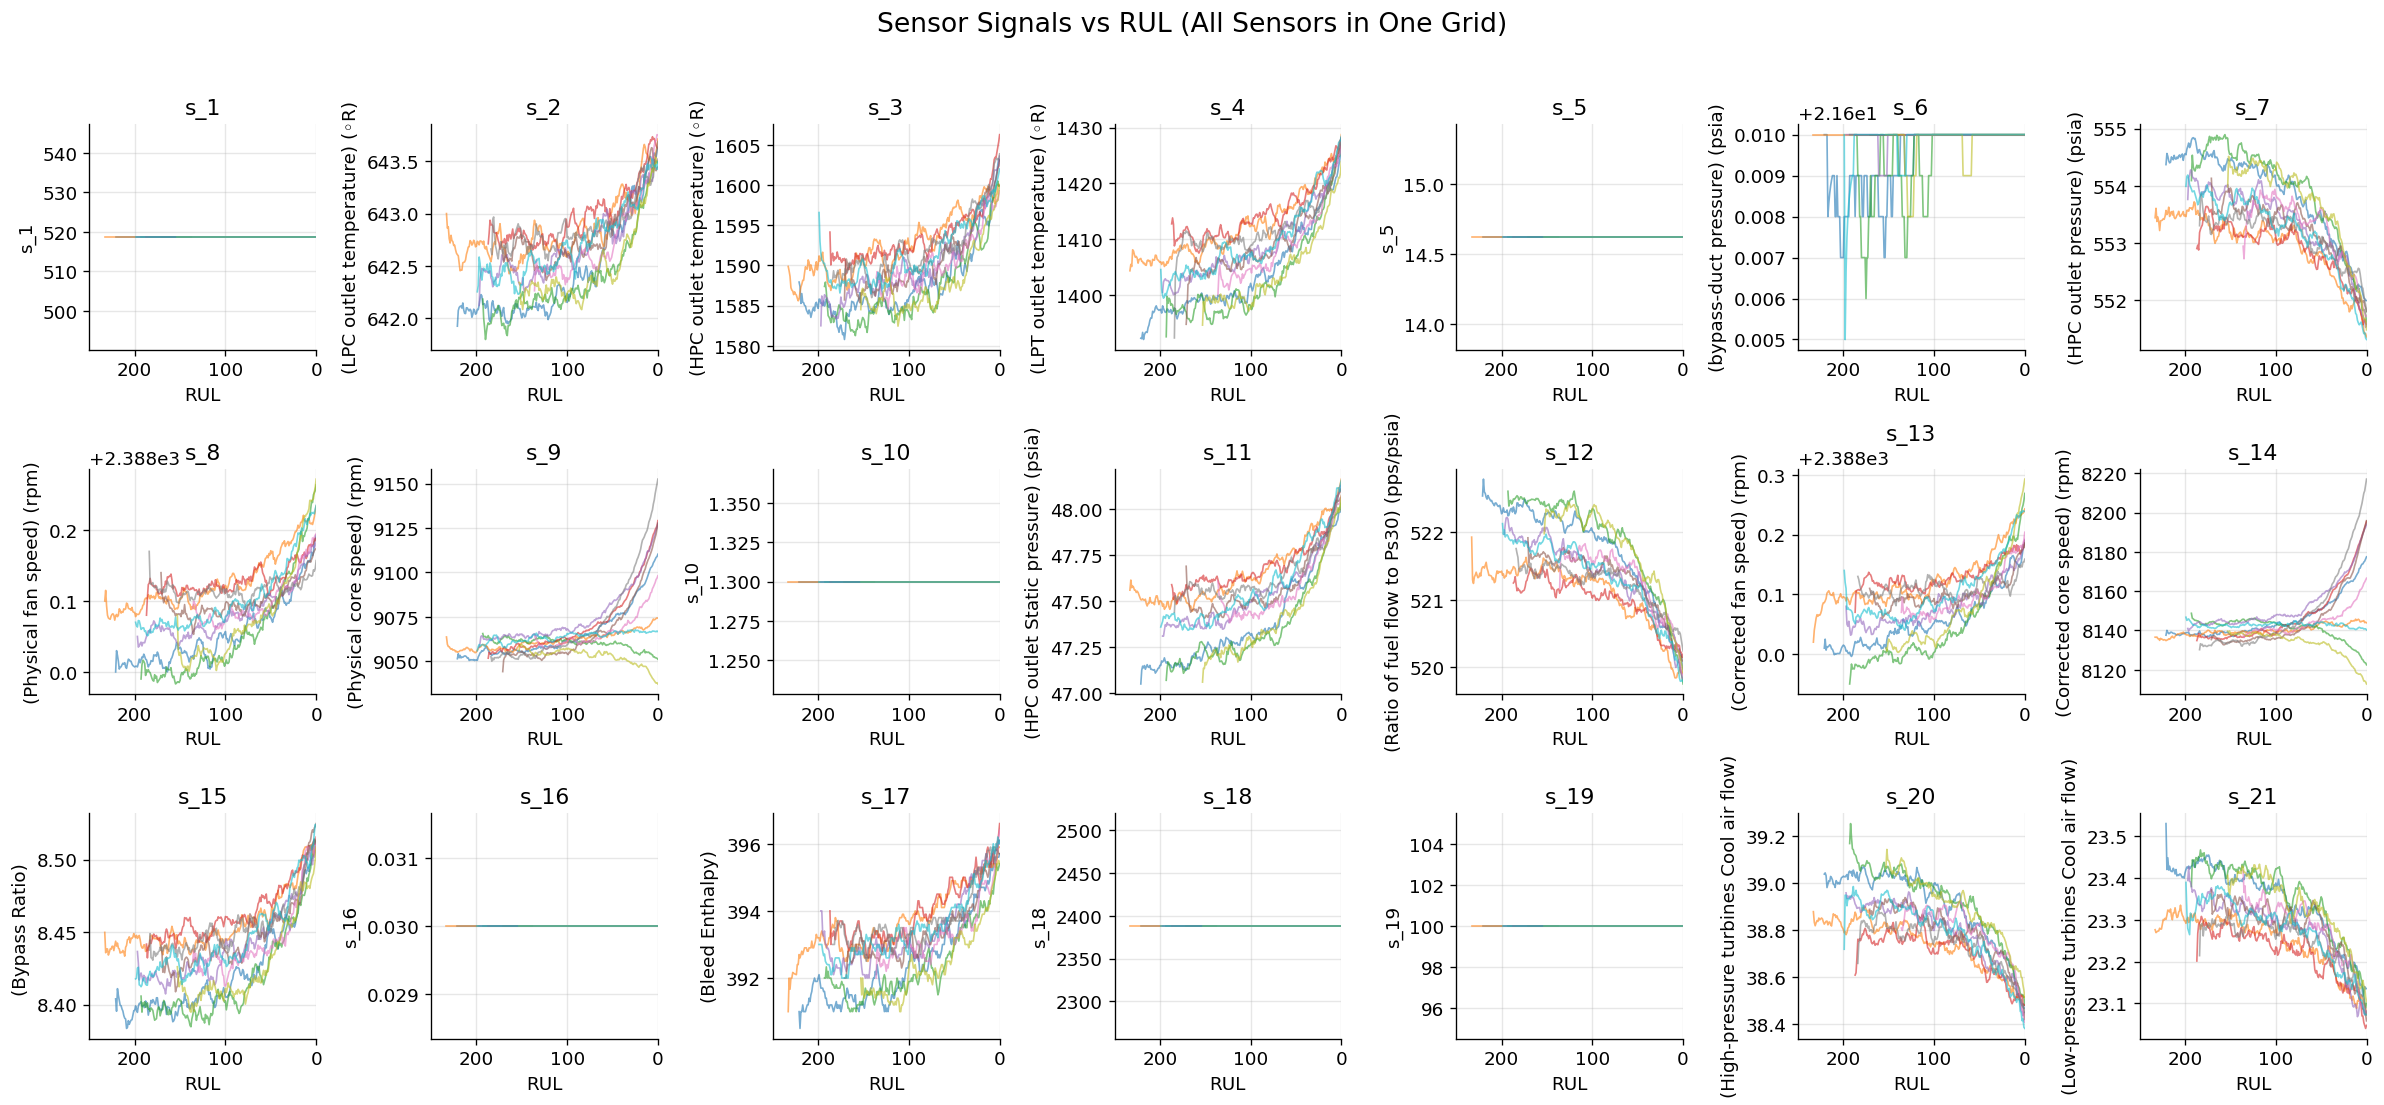

In [135]:
def plot_signal_grid(df, Sensor_dic):
    """Plot all remaining sensor signals vs RUL in a single grid for better visualization."""
    
    # Use only sensors that still exist in the DataFrame
    sensor_cols = [c for c in df.columns if c.startswith('s_')]
    n_sensors = len(sensor_cols)
    
    n_cols = 7
    n_rows = int(np.ceil(n_sensors / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3 * n_rows))
    axes = axes.flatten()  # Flatten in case of multiple rows
    
    for i, sensor in enumerate(sensor_cols):
        ax = axes[i]
        for unit in df['unit_number'].unique():
            if unit % 10 == 0:  # Plot only some units for clarity
                subset = df[df['unit_number'] == unit].sort_values('time_cycles')
                smoothed = subset[sensor].rolling(10, min_periods=1).mean()
                ax.plot(subset['RUL'], smoothed, alpha=0.6, linewidth=1)
        ax.set_xlim(250, 0)
        ax.set_ylabel(Sensor_dic.get(sensor, sensor))  # Fallback if missing in dictionary
        ax.set_xlabel('RUL')
        ax.set_title(sensor)
    
    # Remove any unused axes
    for j in range(n_sensors, len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle('Sensor Signals vs RUL (All Sensors in One Grid)', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Usage:
plot_signal_grid(train, Sensor_dictionary)

Here we can saw again that our choice in dropping ['s_1', 's_5', 's_10', 's_16', 's_18', 's_19'] is justified by the sensor signal distribution as there are constant shown in each of the sensor signal.

📊 Sensor Outlier Summary:
s_1: 0 outliers (0.00%) → Low outlier presence
s_2: 128 outliers (0.62%) → Low outlier presence
s_3: 165 outliers (0.80%) → Low outlier presence
s_4: 120 outliers (0.58%) → Low outlier presence
s_5: 0 outliers (0.00%) → Low outlier presence
s_6: 406 outliers (1.97%) → Moderate outlier presence
s_7: 110 outliers (0.53%) → Low outlier presence
s_8: 320 outliers (1.55%) → Moderate outlier presence
s_9: 1686 outliers (8.17%) → High outlier presence
s_10: 0 outliers (0.00%) → Low outlier presence
s_11: 167 outliers (0.81%) → Low outlier presence
s_12: 146 outliers (0.71%) → Low outlier presence
s_13: 161 outliers (0.78%) → Low outlier presence
s_14: 1543 outliers (7.48%) → High outlier presence
s_15: 120 outliers (0.58%) → Low outlier presence
s_16: 0 outliers (0.00%) → Low outlier presence
s_17: 81 outliers (0.39%) → Low outlier presence
s_18: 0 outliers (0.00%) → Low outlier presence
s_19: 0 outliers (0.00%) → Low outlier presence
s_20: 117 outliers (0.57%) → Low

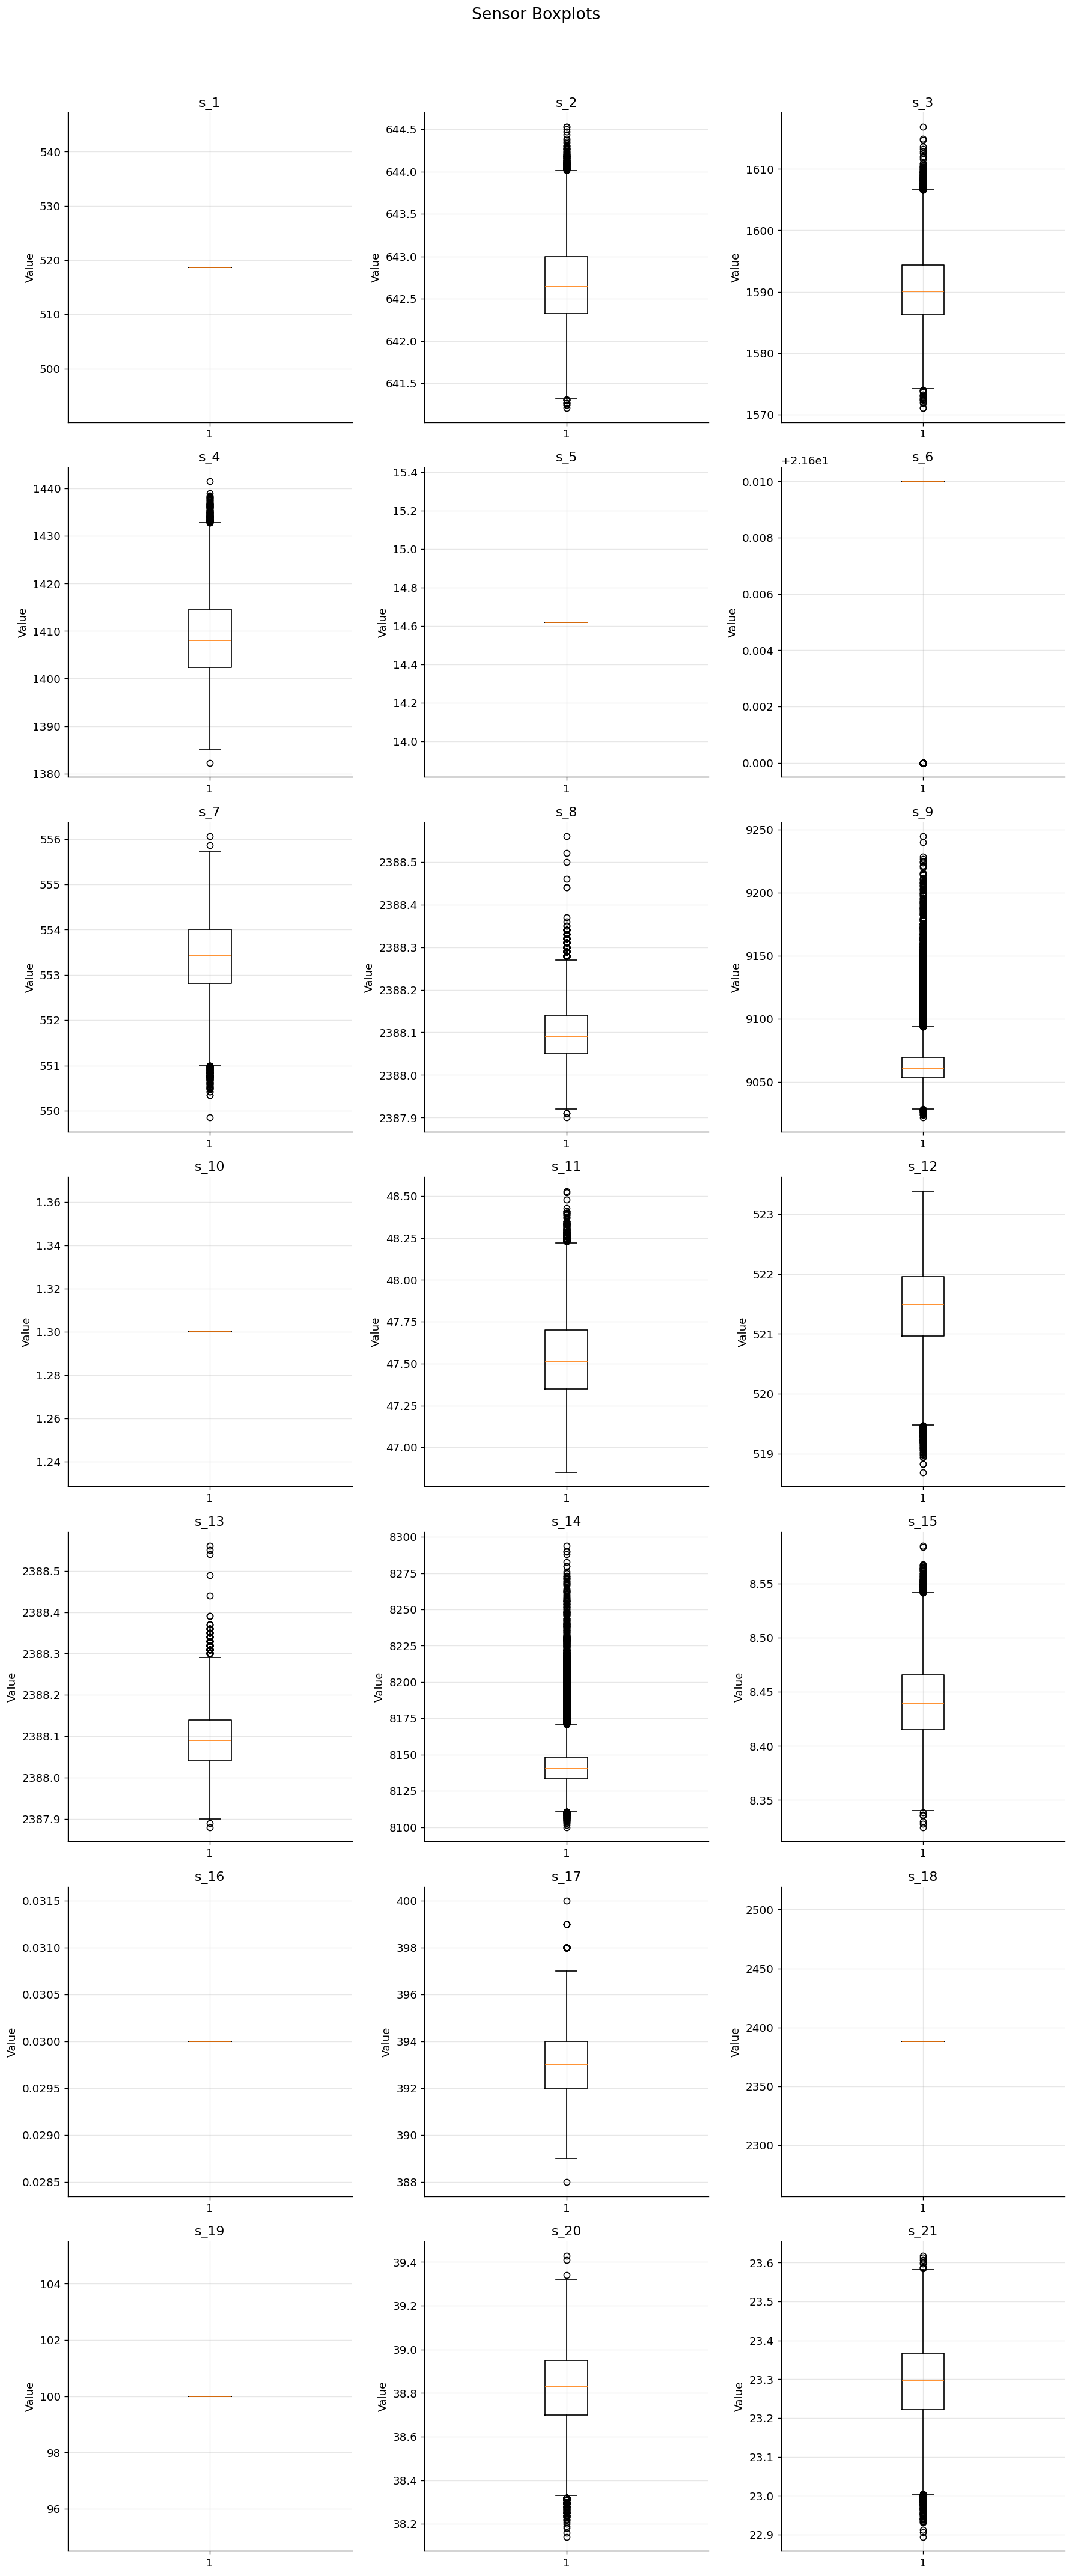

In [134]:
def boxplot_sensors_grid(df, sensor_names, n_cols=3):
    """
    Plot boxplots for multiple sensors in a grid and give textual outlier summary.
    
    Args:
        df: DataFrame containing the sensor columns.
        sensor_names: List of sensor column names (e.g., ['s_1', 's_2', ...]).
        n_cols: Number of columns in the grid.
    """
    # Keep only sensors that exist in df
    sensor_names = [s for s in sensor_names if s in df.columns]

    n_sensors = len(sensor_names)
    n_rows = (n_sensors + n_cols - 1) // n_cols  # ceil division for rows

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
    axes = axes.flatten()  # flatten for easy iteration

    print("📊 Sensor Outlier Summary:")
    for i, sensor in enumerate(sensor_names):
        # Boxplot
        axes[i].boxplot(df[sensor])
        axes[i].set_title(sensor)
        axes[i].set_ylabel('Value')

        # Outlier detection using IQR
        Q1 = df[sensor].quantile(0.25)
        Q3 = df[sensor].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[sensor] < Q1 - 1.5*IQR) | (df[sensor] > Q3 + 1.5*IQR)][sensor]
        n_outliers = len(outliers)
        perc_outliers = n_outliers / len(df) * 100

        # Decide seriousness
        if perc_outliers < 1:
            severity = "Low"
        elif perc_outliers < 5:
            severity = "Moderate"
        else:
            severity = "High"

        print(f"{sensor}: {n_outliers} outliers ({perc_outliers:.2f}%) → {severity} outlier presence")

    # Remove any extra subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle('Sensor Boxplots', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


# Generate sensor_names from remaining columns
sensor_names = [c for c in train.columns if c.startswith('s_')]

# Call the function
boxplot_sensors_grid(train, sensor_names)

s_6 sensor 6 has almost no variation in the boxplot.
Hence we can safely drop s_6.

In [128]:
# Drop from train and test safely
df_train = df_train.drop(columns=['s_6'], errors='ignore')
df_test = df_test.drop(columns=['s_6'], errors='ignore')

# Remaining sensors
remaining_sensors = [c for c in df_train.columns if c.startswith('s_')]

print(f"✅ Dropped s_6 . Remaining: {len(remaining_sensors)}")


✅ Dropped s_6 . Remaining: 14


In [131]:
df_train['unit_number'] = df_train['unit_number'].astype('float64')
df_train['time_cycles'] = df_train['time_cycles'].astype('float64')
df_train['s_17'] = df_train['s_17'].astype('float64')
df_train['RUL'] = df_train['RUL'].astype('float64')
df_train=add_RUL_column(df_train)
df_train.info()


<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_number  20631 non-null  float64
 1   time_cycles  20631 non-null  float64
 2   setting_1    20631 non-null  float64
 3   setting_2    20631 non-null  float64
 4   setting_3    20631 non-null  float64
 5   s_2          20631 non-null  float64
 6   s_3          20631 non-null  float64
 7   s_4          20631 non-null  float64
 8   s_7          20631 non-null  float64
 9   s_8          20631 non-null  float64
 10  s_9          20631 non-null  float64
 11  s_11         20631 non-null  float64
 12  s_12         20631 non-null  float64
 13  s_13         20631 non-null  float64
 14  s_14         20631 non-null  float64
 15  s_15         20631 non-null  float64
 16  s_17         20631 non-null  float64
 17  s_20         20631 non-null  float64
 18  s_21         20631 non-null  float64
 19  RUL          20

In [132]:
# Save
df_train.to_csv(PROCESSED_DIR / 'train_cleaned.csv', index=False)
df_test.to_csv(PROCESSED_DIR / 'test_cleaned.csv', index=False)
print(f"\n✅ Cleaned & engineered data saved to {PROCESSED_DIR}")



✅ Cleaned & engineered data saved to ../data/processed
